In [1]:
#This

In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier

from sklearn.model_selection import RandomizedSearchCV

from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

In [3]:
#Loading Data to pandas

In [4]:
df=pd.read_csv("/content/WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [5]:
df.shape #This will tell us how many rows and columns our csv file has


(7043, 21)

In [6]:
df.head() # and this will print the first 4 rows of the csv file

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
df.info() # This will let us check if there are columns with null info(vo missing values  )
# Also we can check the type of data in each column

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
#We can drop the c ustomer ID column because it is not important

In [9]:
df=df.drop(columns=['customerID'])

In [10]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [11]:
#To make sure our data is consistent and clean , we should print all the unique values for categorical columns
numercial_data=['TotalCharges','MonthlyCharges','tenure']
for column in df.columns:
  if column not in numercial_data:
    print(f'{column}: {df[column].unique()}')
    print('*'*25)

gender: ['Female' 'Male']
*************************
SeniorCitizen: [0 1]
*************************
Partner: ['Yes' 'No']
*************************
Dependents: ['No' 'Yes']
*************************
PhoneService: ['No' 'Yes']
*************************
MultipleLines: ['No phone service' 'No' 'Yes']
*************************
InternetService: ['DSL' 'Fiber optic' 'No']
*************************
OnlineSecurity: ['No' 'Yes' 'No internet service']
*************************
OnlineBackup: ['Yes' 'No' 'No internet service']
*************************
DeviceProtection: ['No' 'Yes' 'No internet service']
*************************
TechSupport: ['No' 'Yes' 'No internet service']
*************************
StreamingTV: ['No' 'Yes' 'No internet service']
*************************
StreamingMovies: ['No' 'Yes' 'No internet service']
*************************
Contract: ['Month-to-month' 'One year' 'Two year']
*************************
PaperlessBilling: ['Yes' 'No']
*************************
PaymentMethod: 

In [12]:
#The TotalCharges column is stored as a string instead of numeric,and some enteries might be missing because an empty string is still a string

In [13]:
#let us check for spaces in the TotalCharges column
df[df["TotalCharges"]==' ']

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [14]:
len(df[df["TotalCharges"]==' '])

11

In [15]:
#as we can see, when the tenur is 0 the total charges =0
#and then we can replace all the empty spaces and change the values from strings to float

In [16]:
df["TotalCharges"]=df["TotalCharges"].replace({" ":"0.0"})

In [17]:
df["TotalCharges"]=df["TotalCharges"].astype(float)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [19]:
print(df["Churn"].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


**Data analysis segment**

In [20]:
def histo_plot(df,colname):
  plt.figure(figsize=(7,5))
  sns.histplot(df[colname],kde=True)
  plt.title(f'Distribution of {colname}')
  #calculating mean and median
  colmean=df[colname].mean()
  colmedian=df[colname].median()
  plt.axvline(colmean,color='red',linestyle='--',label="Mean")
  plt.axvline(colmedian,color='green',linestyle='-',label="Median")
  plt.legend()
  plt.show()

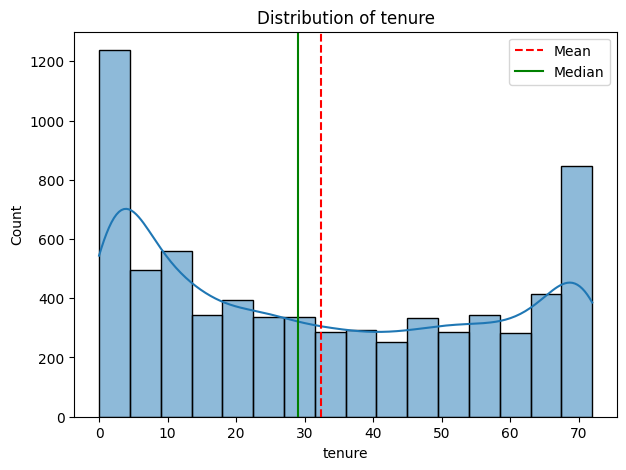

In [21]:
histo_plot(df,"tenure")

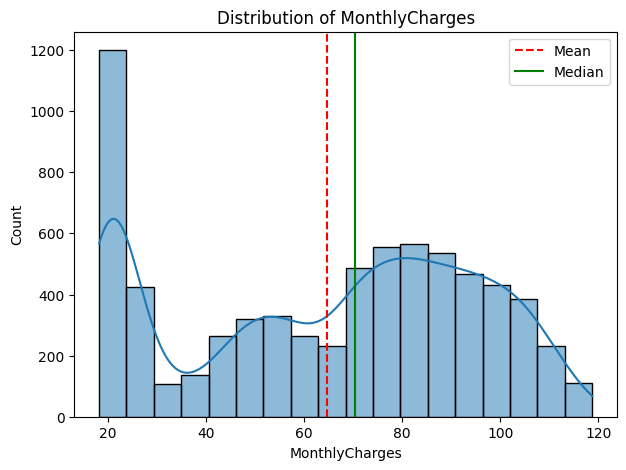

In [22]:
histo_plot(df,"MonthlyCharges")

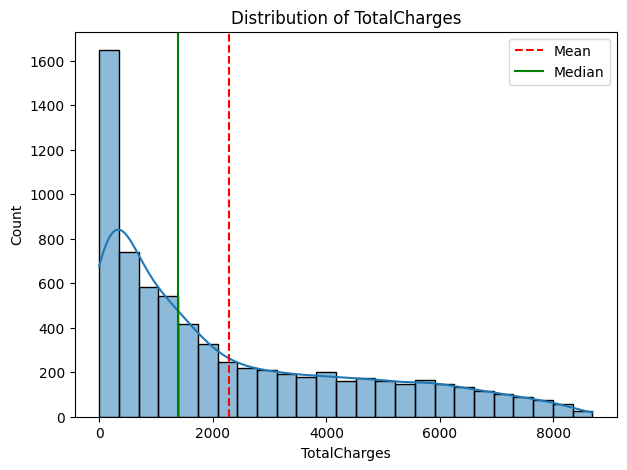

In [23]:
histo_plot(df,"TotalCharges")

**Box plot for numerical features**

In [24]:
def Plot_boxplot(df,colname):
  plt.figure(figsize=(7,5))
  sns.boxplot(y=df[colname])
  plt.title(f'box plot of {colname}')
  plt.ylabel(colname)
  plt.show()

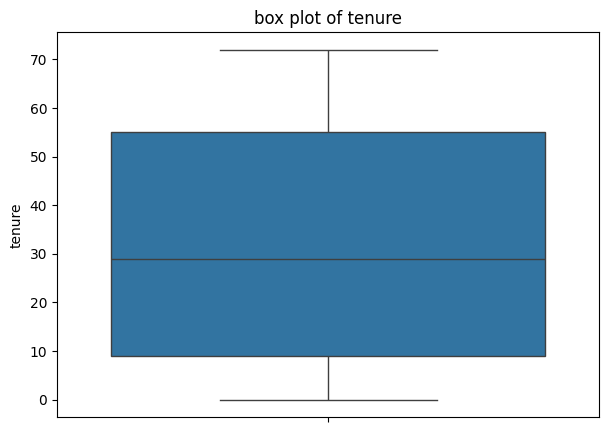

In [25]:
Plot_boxplot(df,"tenure")

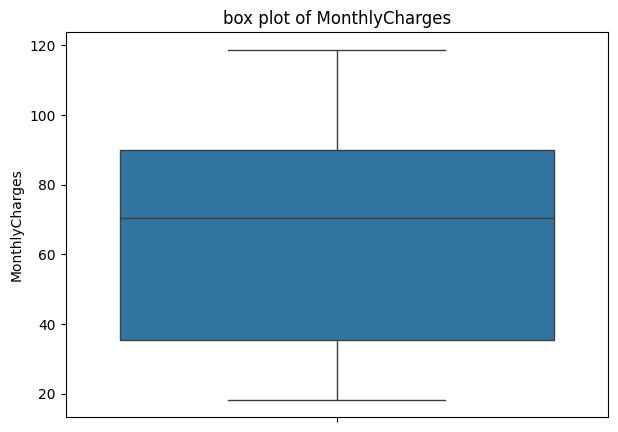

In [26]:
Plot_boxplot(df,"MonthlyCharges")

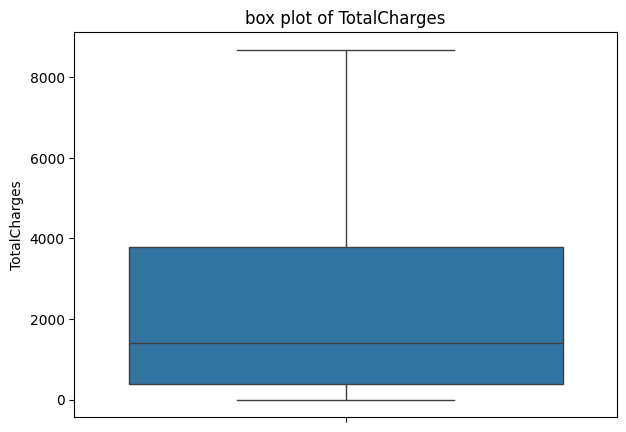

In [27]:
Plot_boxplot(df,"TotalCharges")

**Correlation heatmap for out data**

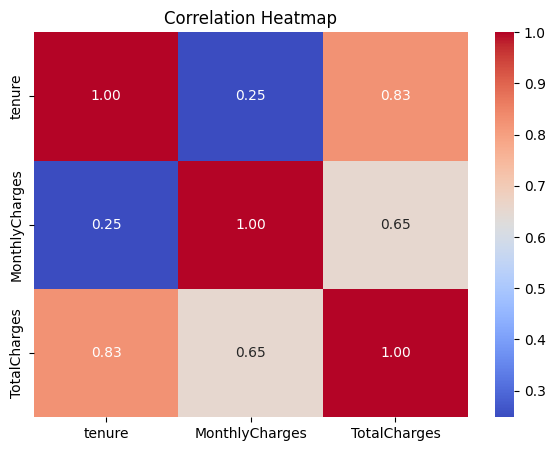

In [28]:
# correlation matrix - heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(df[["tenure", "MonthlyCharges", "TotalCharges"]].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**categorical features analysis**

In [29]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


**countblot for categorical features**

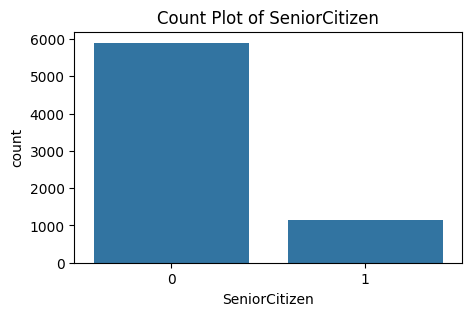

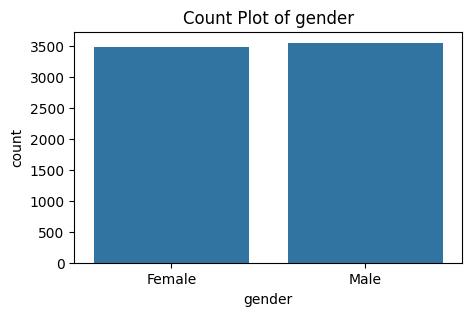

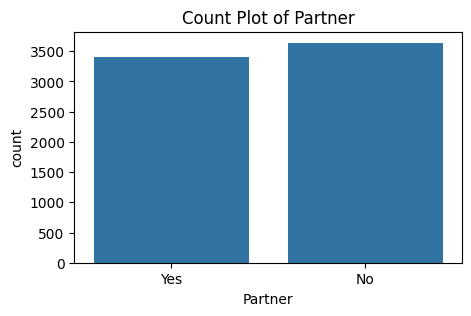

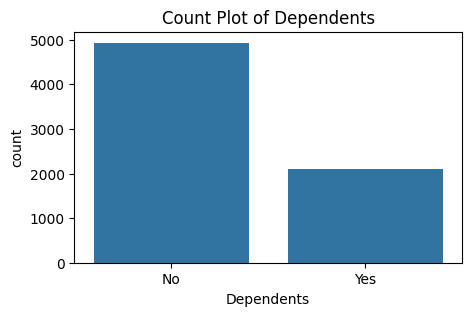

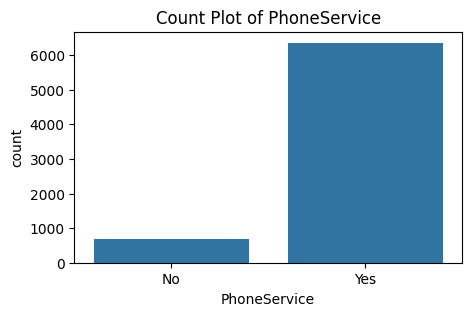

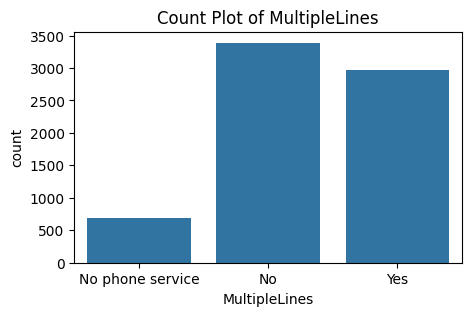

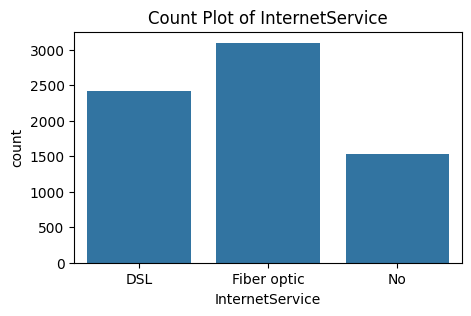

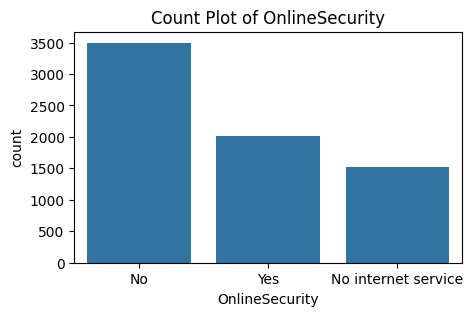

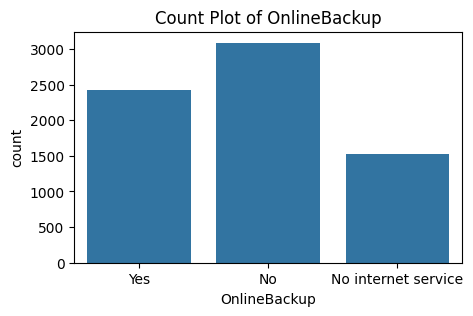

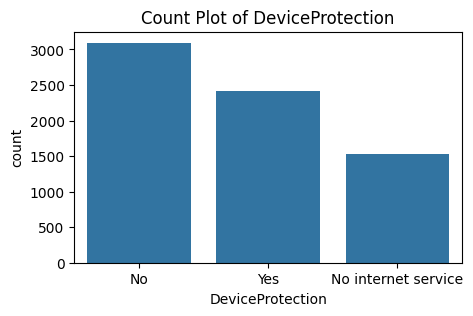

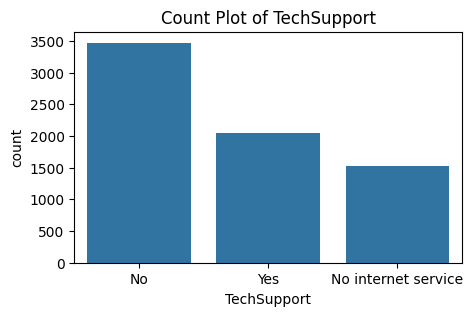

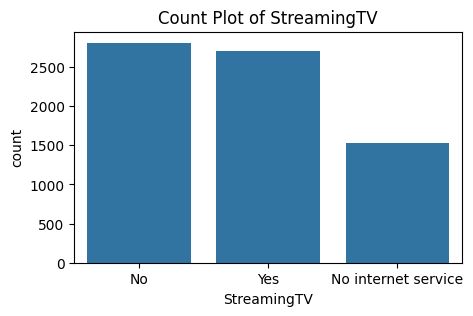

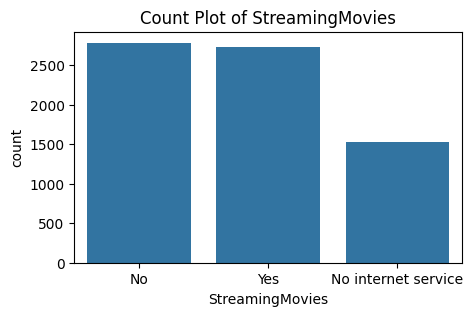

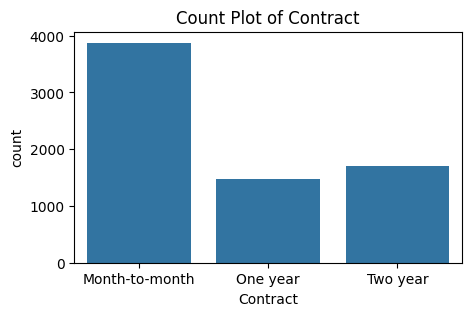

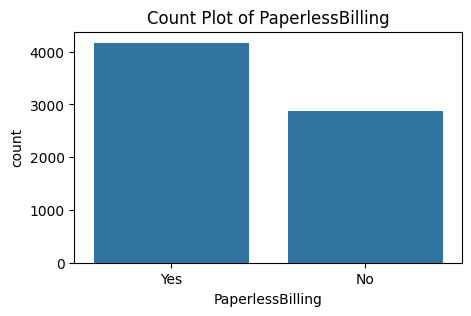

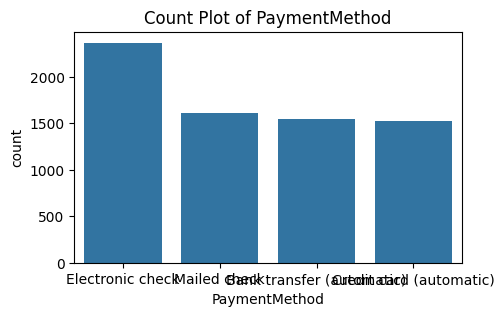

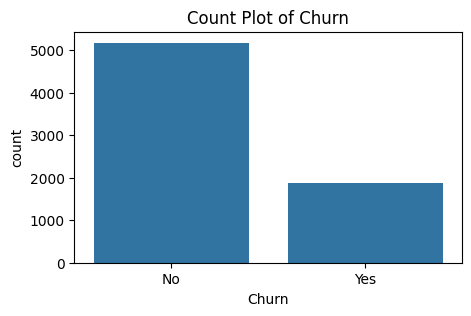

In [31]:
object_cols = df.select_dtypes(include="object").columns.to_list()

object_cols = ["SeniorCitizen"] + object_cols

for col in object_cols:
  plt.figure(figsize=(5, 3))
  sns.countplot(x=df[col])
  plt.title(f"Count Plot of {col}")
  plt.show()

**Data Processing**

In [32]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes


In [33]:
df["Churn"] = df["Churn"].replace({"Yes": 1, "No": 0})

/tmp/ipykernel_5100/2364848822.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df["Churn"] = df["Churn"].replace({"Yes": 1, "No": 0})


In [34]:
df.head(3)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


In [35]:
print(df["Churn"].value_counts())

Churn
0    5174
1    1869
Name: count, dtype: int64


In [36]:
# identifying columns with object data type
objcol = df.select_dtypes(include="object").columns
print(objcol)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [37]:
# encode the data in all the categorical columns (the ones wit hobject data type)
encoders = {}

# apply label and storing encoders
for col in objcol:
  label_encoder = LabelEncoder()
  df[col] = label_encoder.fit_transform(df[col])
  encoders[col] = label_encoder


# save the encoders to a pickle file
with open("encoders.pkl", "wb") as f:
  pickle.dump(encoders, f)


In [38]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}

In [39]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


**Training**

In [40]:
a = df.drop(columns=["Churn"])
b = df["Churn"]

In [41]:
#splitting the dataset
a_train, a_test, b_train, b_test = train_test_split(a, b, test_size=0.2, random_state=42)


In [42]:
print(b_train.shape)

(5634,)


In [43]:
print(b_train.value_counts())

Churn
0    4138
1    1496
Name: count, dtype: int64


In [44]:
smote = SMOTE(random_state=42)

In [45]:
a_train_smote, b_train_smote = smote.fit_resample(a_train, b_train)

In [46]:
print(b_train_smote.shape)

(8276,)


In [47]:
print(b_train_smote.value_counts())#balanced

Churn
0    4138
1    4138
Name: count, dtype: int64


**Model Training**

In [48]:

# models = {
#     "Decision Tree": DecisionTreeClassifier(random_state=42),
#     "Random Forest": RandomForestClassifier(random_state=42),
#     "XGBoost": XGBClassifier(random_state=42)
# }

**Training parameters**

In [49]:
dt_params = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

rf_params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2]
}

xgb_params = {
    "n_estimators": [100, 200],
    "learning_rate": [0.01, 0.1],
    "max_depth": [3, 6],
    "subsample": [0.8, 1]
}

In [50]:
#Models dectioniry
models = {
    "Decision Tree": (DecisionTreeClassifier(random_state=42), dt_params),
    "Random Forest": (RandomForestClassifier(random_state=42), rf_params),
    "XGBoost": (XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'), xgb_params)
}


**Traning and tunning**

In [51]:
Training_models = {}

for name, (model, params) in models.items():
    print(f"Tuning {name}...")

    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params,
        n_iter=10,
        cv=10,
        scoring='f1',   # better for churn
        n_jobs=-1,
        random_state=42
    )

    random_search.fit(a_train_smote, b_train_smote)

    Training_models[name] = random_search.best_estimator_

    print(f"Best Parameters for {name}: {random_search.best_params_}")
    print(f"Best F1 Score: {random_search.best_score_:.4f}")
    print("-" * 70)


Tuning Decision Tree...
Best Parameters for Decision Tree: {'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 10}
Best F1 Score: 0.8003
----------------------------------------------------------------------
Tuning Random Forest...
Best Parameters for Random Forest: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 20}
Best F1 Score: 0.8448
----------------------------------------------------------------------
Tuning XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [06:56:09] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Best Parameters for XGBoost: {'subsample': 1, 'n_estimators': 200, 'max_depth': 6, 'learning_rate': 0.1}
Best F1 Score: 0.8331
----------------------------------------------------------------------


The random forest has the best performance and an f1 score of 0.8368

In [52]:
rfc = RandomForestClassifier(random_state=42)

In [53]:
rfc.fit(a_train_smote, b_train_smote)

RandomForestClassifier(random_state=42)

In [54]:
print(b_test.value_counts())

Churn
0    1036
1     373
Name: count, dtype: int64


**Model Evalution**

In [57]:
best_rfc = Training_models["Random Forest"]

b_test_pred = best_rfc.predict(a_test)

print("Accuracy Score:\n", accuracy_score(b_test, b_test_pred))
print("Confusion Matrix:\n", confusion_matrix(b_test, b_test_pred))
print("Classification Report:\n", classification_report(b_test, b_test_pred))

Accuracy Score:
 0.7764371894960965
Confusion Matrix:
 [[860 176]
 [139 234]]
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.83      0.85      1036
           1       0.57      0.63      0.60       373

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.72      1409
weighted avg       0.78      0.78      0.78      1409



In [59]:
#saving model
model = {"model": rfc, "features_names": a.columns.tolist()}


with open("customer_churn_model.pkl", "wb") as f:
  pickle.dump(model, f)

In [60]:
# load teh saved model and the feature names

with open("customer_churn_model.pkl", "rb") as f:
  model= pickle.load(f)

loaded_model = model["model"]
feature_names = model["features_names"]

In [62]:
print(loaded_model)

RandomForestClassifier(random_state=42)


In [63]:
print(feature_names)

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges']


In [64]:
input_data = {
    'gender': 'Female',
    'SeniorCitizen': 0,
    'Partner': 'Yes',
    'Dependents': 'No',
    'tenure': 1,
    'PhoneService': 'No',
    'MultipleLines': 'No phone service',
    'InternetService': 'DSL',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'Yes',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'No',
    'StreamingMovies': 'No',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 29.85,
    'TotalCharges': 29.85
}


input_data_df = pd.DataFrame([input_data])

with open("encoders.pkl", "rb") as f:
  encoders = pickle.load(f)


# encode categorical featires using teh saved encoders
for column, encoder in encoders.items():
  input_data_df[column] = encoder.transform(input_data_df[column])

# make a prediction
prediction = loaded_model.predict(input_data_df)
pred_prob = loaded_model.predict_proba(input_data_df)

print(prediction)

# results
print(f"Prediction: {'Churn' if prediction[0] == 1 else 'No Churn'}")
print(f"Prediciton Probability: {pred_prob}")

[0]
Prediction: No Churn
Prediciton Probability: [[0.78 0.22]]


In [65]:
encoders

{'gender': LabelEncoder(),
 'Partner': LabelEncoder(),
 'Dependents': LabelEncoder(),
 'PhoneService': LabelEncoder(),
 'MultipleLines': LabelEncoder(),
 'InternetService': LabelEncoder(),
 'OnlineSecurity': LabelEncoder(),
 'OnlineBackup': LabelEncoder(),
 'DeviceProtection': LabelEncoder(),
 'TechSupport': LabelEncoder(),
 'StreamingTV': LabelEncoder(),
 'StreamingMovies': LabelEncoder(),
 'Contract': LabelEncoder(),
 'PaperlessBilling': LabelEncoder(),
 'PaymentMethod': LabelEncoder()}